In [2]:
import os, time

import math
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable 
from matplotlib.ticker import ScalarFormatter

# from skrmt.ensemble.spectral_law import MarchenkoPasturDistribution

from global_chanju.paulplot.styles import nice_style
from global_chanju.paulplot.rc_setter import set_rc
from global_chanju.paulplot.rc_setter import get_rc
from global_chanju.utils.statistics import asym_err
from global_chanju.utils.statistics import f_bin
from global_chanju.paulplot.styles import base_ten

set_rc()

In [3]:
plot_dir = "../images/5.real/"
data_dir = "../data/5.real/"
os.system("mkdir -p " + plot_dir)
os.system("mkdir -p " + data_dir)

0

In [4]:
def _extract_metric_at_epoch(eval_epochs, metric_values, epoch=None):
    eval_epochs = np.asarray(eval_epochs)
    metric_values = np.asarray(metric_values, dtype=float)

    if metric_values.size == 0:
        return np.nan

    if epoch is None:
        return float(metric_values[-1])

    matches = np.where(eval_epochs == epoch)[0]
    if len(matches) == 0:
        return np.nan
    return float(metric_values[matches[-1]])

In [5]:
data = np.load(data_dir + "exp2_dnn_SMALL_sgd_relu_v4.npz", allow_pickle=True)
metric_key = "test_mae_years"
epoch = 300

In [6]:
lr = np.asarray(data["lr"], dtype=float)
inv_sigma_w = np.asarray(data["inv_sigma_w"], dtype=float)

lr_vals = np.sort(np.unique(lr))
inv_sigma_vals = np.sort(np.unique(inv_sigma_w))

In [7]:
phase_matrix = np.full((len(lr_vals), len(inv_sigma_vals)), np.nan, dtype=float)
counts_matrix = np.zeros((len(lr_vals), len(inv_sigma_vals)), dtype=int)

scalar_metric_keys = {
    "final_train_loss_std_mse",
    "final_test_loss_std_mse",
    "final_train_mae_years",
    "final_test_mae_years",
    "final_train_mse_years",
    "final_test_mse_years",
}

for i_lr, lr_val in enumerate(lr_vals):
    for j_inv, inv_val in enumerate(inv_sigma_vals):
        mask = (lr == lr_val) & (inv_sigma_w == inv_val)
        idxs = np.where(mask)[0]

        vals = []
        for idx in idxs:
            if metric_key in scalar_metric_keys:
                v = float(data[metric_key][idx])
            else:
                eval_epochs = data["eval_epochs"][idx]
                metric_values = data[metric_key][idx]
                v = _extract_metric_at_epoch(eval_epochs, metric_values, epoch=epoch)

            if np.isfinite(v):
                vals.append(v)
            if v>100:
                vals.append(100)

        if len(vals) > 0:
            phase_matrix[i_lr, j_inv] = float(np.mean(vals))
            counts_matrix[i_lr, j_inv] = len(vals)

/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_76041/806237418.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels(


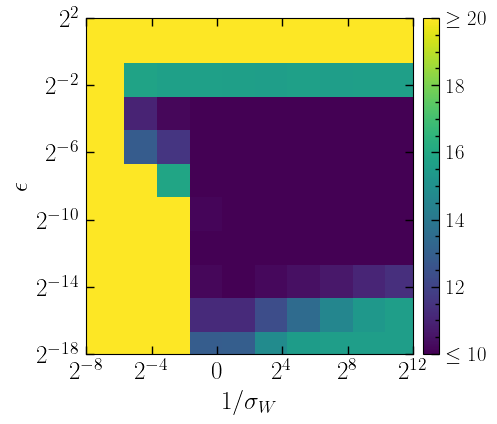

In [8]:
color_cut = 20
set_rc(scale=1.)

fig = plt.figure(
    figsize=(get_rc()['W']*get_rc()['r']*1.08,
             get_rc()['W']*get_rc()['r']),
)

axs = fig.add_subplot(111)

X, Y = np.meshgrid(inv_sigma_vals, lr_vals)

# Experimental phase diagram
im = axs.pcolormesh(X, Y, phase_matrix,
                    vmin=10, vmax=20,
                    cmap='viridis',
                    shading='auto')

nice_style(axs, 
           ylim=(2**-18, 2**2),
           xlim=(2**-8, 2**12),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True,
          )
axs.set_xscale('log', base=2)
axs.set_yscale('log', base=2)

axs.set_xticks(
    ticks=[2**-8, 2**-4, 2**0, 2**4, 2**8, 2**12],
    labels=[r"$2^{-8}$", r"$2^{-4}$", r"$0$", r"$2^4$", r"$2^8$", r"$2^{12}$"]
)

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)
cb.ax.set_yticklabels(
    [r"$\leq 10$", "12", "14", "16", "18", r"$\geq 20$"],
    fontsize=15
)

plt.savefig(plot_dir + "phase_diagram_faces_log.pdf", bbox_inches="tight")

plt.show()

In [9]:
data = np.load(data_dir + "exp2_dnn_BIG_sgd_relu_v6.npz", allow_pickle=True)
metric_key = "test_mae_years"
epoch = 300

lr = np.asarray(data["lr"], dtype=float)
inv_sigma_w = np.asarray(data["inv_sigma_w"], dtype=float)

lr_vals = np.sort(np.unique(lr))
inv_sigma_vals = np.sort(np.unique(inv_sigma_w))

phase_matrix = np.full((len(lr_vals), len(inv_sigma_vals)), np.nan, dtype=float)
counts_matrix = np.zeros((len(lr_vals), len(inv_sigma_vals)), dtype=int)

scalar_metric_keys = {
    "final_train_loss_std_mse",
    "final_test_loss_std_mse",
    "final_train_mae_years",
    "final_test_mae_years",
    "final_train_mse_years",
    "final_test_mse_years",
}

for i_lr, lr_val in enumerate(lr_vals):
    for j_inv, inv_val in enumerate(inv_sigma_vals):
        mask = (lr == lr_val) & (inv_sigma_w == inv_val)
        idxs = np.where(mask)[0]

        vals = []
        for idx in idxs:
            if metric_key in scalar_metric_keys:
                v = float(data[metric_key][idx])
            else:
                eval_epochs = data["eval_epochs"][idx]
                metric_values = data[metric_key][idx]
                v = _extract_metric_at_epoch(eval_epochs, metric_values, epoch=epoch)

            if np.isfinite(v):
                vals.append(v)
            if v>100:
                vals.append(100)

        if len(vals) > 0:
            phase_matrix[i_lr, j_inv] = float(np.mean(vals))
            counts_matrix[i_lr, j_inv] = len(vals)

/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_76041/1323994804.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels(


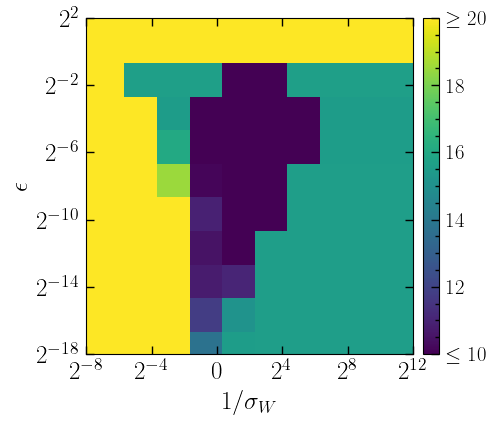

In [10]:
color_cut = 20
set_rc(scale=1.)

fig = plt.figure(
    figsize=(get_rc()['W']*get_rc()['r']*1.08,
             get_rc()['W']*get_rc()['r']),
)

axs = fig.add_subplot(111)

X, Y = np.meshgrid(inv_sigma_vals, lr_vals)

# Experimental phase diagram
im = axs.pcolormesh(X, Y, phase_matrix,
                    vmin=10, vmax=20,
                    cmap='viridis',
                    shading='auto')

nice_style(axs, 
           ylim=(2**-18, 2**2),
           xlim=(2**-8, 2**12),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True,
          )
axs.set_xscale('log', base=2)
axs.set_yscale('log', base=2)

axs.set_xticks(
    ticks=[2**-8, 2**-4, 2**0, 2**4, 2**8, 2**12],
    labels=[r"$2^{-8}$", r"$2^{-4}$", r"$0$", r"$2^4$", r"$2^8$", r"$2^{12}$"]
)

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)
cb.ax.set_yticklabels(
    [r"$\leq 10$", "12", "14", "16", "18", r"$\geq 20$"],
    fontsize=15
)

plt.savefig(plot_dir + "phase_diagram_faces_BIG_log.pdf", bbox_inches="tight")

plt.show()

In [11]:
data = np.load(data_dir + "conductivity_SVD_dnn_SMALL_sgd_relu_v4.npz", allow_pickle=True)
metric_key = "test_mae_years"
epoch = 1000

lr = np.asarray(data["lr"], dtype=float)
inv_sigma_w = np.asarray(data["inv_sigma_w"], dtype=float)

lr_vals = np.sort(np.unique(lr))
inv_sigma_vals = np.sort(np.unique(inv_sigma_w))

phase_matrix = np.full((len(lr_vals), len(inv_sigma_vals)), np.nan, dtype=float)
counts_matrix = np.zeros((len(lr_vals), len(inv_sigma_vals)), dtype=int)

scalar_metric_keys = {
    "final_train_loss_std_mse",
    "final_test_loss_std_mse",
    "final_train_mae_years",
    "final_test_mae_years",
    "final_train_mse_years",
    "final_test_mse_years",
}

for i_lr, lr_val in enumerate(lr_vals):
    for j_inv, inv_val in enumerate(inv_sigma_vals):
        mask = (lr == lr_val) & (inv_sigma_w == inv_val)
        idxs = np.where(mask)[0]

        vals = []
        for idx in idxs:
            if metric_key in scalar_metric_keys:
                v = float(data[metric_key][idx])
            else:
                eval_epochs = data["eval_epochs"][idx]
                metric_values = data[metric_key][idx]
                v = _extract_metric_at_epoch(eval_epochs, metric_values, epoch=epoch)

            if np.isfinite(v):
                vals.append(v)
            if v>100:
                vals.append(100)

        if len(vals) > 0:
            phase_matrix[i_lr, j_inv] = float(np.mean(vals))
            counts_matrix[i_lr, j_inv] = len(vals)

/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_76041/4281370974.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels(


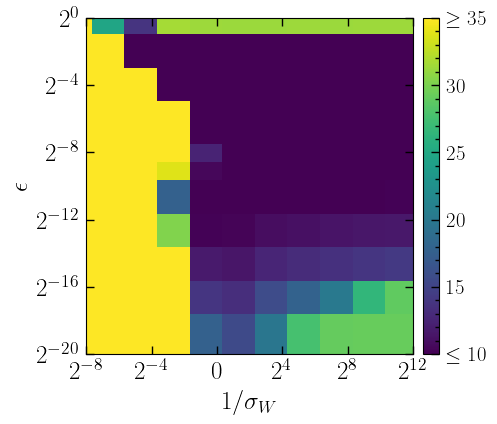

In [12]:
color_cut = 35
set_rc(scale=1.)

fig = plt.figure(
    figsize=(get_rc()['W']*get_rc()['r']*1.08,
             get_rc()['W']*get_rc()['r']),
)

axs = fig.add_subplot(111)

X, Y = np.meshgrid(inv_sigma_vals, lr_vals)

# Experimental phase diagram
im = axs.pcolormesh(X, Y, phase_matrix,
                    vmin=10, vmax=35,
                    cmap='viridis',
                    shading='auto')

nice_style(axs, 
           ylim=(2**-20, 2**0),
           xlim=(2**-8, 2**12),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True,
          )
axs.set_xscale('log', base=2)
axs.set_yscale('log', base=2)

axs.set_xticks(
    ticks=[2**-8, 2**-4, 2**0, 2**4, 2**8, 2**12],
    labels=[r"$2^{-8}$", r"$2^{-4}$", r"$0$", r"$2^4$", r"$2^8$", r"$2^{12}$"]
)

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)
cb.ax.set_yticklabels(
    [r"$\leq 10$", "15", "20", "25", "30", r"$\geq 35$"],
    fontsize=15
)

plt.savefig(plot_dir + "phase_diagram_cond_log.pdf", bbox_inches="tight")

plt.show()